# Flight Final Descent Anomaly Detection and Classification
Contributors: Elan Wilkinson, Melissa Short, Nicholas Short
----


---

## Set Up Necessary Dependencies
### Install Required Libraries

In [ ]:
!pip install --disable-pip-version-check -q pip --upgrade > /dev/null
!pip install --disable-pip-version-check -q wrapt --upgrade > /dev/null

!pip install --disable-pip-version-check -q awscli boto3

!pip install --disable-pip-version-check -q sagemaker
!pip install --disable-pip-version-check -q smdebug
!pip install --disable-pip-version-check -q sagemaker-experiments

!pip install --disable-pip-version-check -q PyAthena

!pip install --disable-pip-version-check -q awswrangler

!conda install -y zip

!pip install --upgrade tensorflow

#### Import Necessary Libraries

In [ ]:
import random
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import boto3
import sagemaker
from pyathena import connect
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import tarfile
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ProcessPoolExecutor
import joblib
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import DataLoader, TensorDataset
from tensorflow.keras.optimizers import Adam
from keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, MMaxPooling1D, Flatten,
from keras.models import Sequential


### Import Training Data from CSV

#### If needing to connect to drive from Google Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Create DataFrame from CSV

In [ ]:
#df = pd.read_csv("/home/sagemaker-user/FlightFinalApproachAnomalyDetection/training_flight_data.csv")
df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/training_flight_data.csv")

#### Set Column Names

In [ ]:
df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg', 'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

#### Get Float Columns

In [ ]:
float_columns = [col for col in df.columns if col not in ['sample_id', 'time_step', 'label'] and df[col].dtype == 'float64']


### Incorporate Arrival Airport into Data
#### Bring in data from CSV

In [ ]:
sample_ids = df['sample_id'].unique()
flight_metadata_df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/DASHlink_full_fourclass_raw_meta (1).csv")
train_flight_metadata_train = flight_metadata_df[flight_metadata_df['data_instance'].isin(sample_ids)]

#### Filter down to just arrival airport and associated sample ID

In [ ]:
arrival_and_samp = train_flight_metadata_train.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp['arrival_airport_catenc'], arrival_airport_mapping = pd.factorize(arrival_and_samp['arrival_airport'])
arrival_and_samp.drop(columns=['arrival_airport'], inplace=True)
arrival_and_samp['arrival_airport_catenc'] = arrival_and_samp['arrival_airport_catenc'].astype(float)
arrival_and_samp.head()

,sample_id,arrival_airport_catenc
0,0,0.0
2,2,0.0
3,3,1.0
5,5,0.0
6,6,2.0


#### Balance Classes in Training Data

In [ ]:
num_unique = (int)(len((df[df['label'] == 3]))/160)
rand_zeroes = df[df['label'] == 0]['sample_id'].unique()
unique_zeros = random.choices(rand_zeroes, k=num_unique)
rand_ones = df[df['label'] == 1]['sample_id'].unique()
unique_ones = random.choices(rand_ones, k=num_unique)
rand_twos = df[df['label'] == 2]['sample_id'].unique()
unique_twos = random.choices(rand_twos, k=num_unique)
sampleids_to_keep = df[df['label'] == 3]['sample_id'].unique().tolist()
sampleids_to_keep.extend(unique_ones)
sampleids_to_keep.extend(unique_twos)
sampleids_to_keep.extend(unique_zeros)

training_df = df[df['sample_id'].isin(sampleids_to_keep)]

#### Append Categorically Encoded Arrival

In [ ]:
training_df = training_df.merge(arrival_and_samp, on='sample_id', how='left')

#### Data Scaling

In [ ]:
df_scaled = training_df.copy()
scalers = []

scalers_directory = os.path.join(os.getcwd(), 'scalers')
if not os.path.exists(scalers_directory):
    os.makedirs(scalers_directory)

for col in float_columns:
  new_scaler = MinMaxScaler()
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")
  df_scaled[col] = new_scaler.fit_transform(df_scaled[[col]])
  scalers.append(new_scaler)
  with open(scaler_name, 'wb') as scaler_file:
    pickle.dump(new_scaler, scaler_file)

train_x = df_scaled.copy()
train_x = train_x.drop(columns=['label','sample_id'])
train_y = df_scaled['label']

##### Open Scalers

In [ ]:
scalers = []

for col in float_columns:
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")

  with open(scaler_name, 'rb') as file:
      loaded_scaler = pickle.load(file)
      #df_scaled[col] = loaded_scaler.transform(df_scaled[[col]])
      scalers.append(loaded_scaler)

### Import and Prepare Validation Data
---

In [ ]:
valid_df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/valid_flight_data.csv")
valid_df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg',
'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

In [ ]:
valid_ids = valid_df['sample_id'].unique()
print(valid_ids)
flight_metadata_valid = flight_metadata_df[flight_metadata_df['data_instance'].isin(valid_ids)]
flight_metadata_valid.head()
arrival_and_samp = flight_metadata_valid.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp
valid_df = valid_df.merge(arrival_and_samp, on='sample_id', how='left')
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(dict(enumerate(arrival_airport_mapping)))
valid_df.tail()

[   15    20    21 ... 99806 99809 99810]


,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport,arrival_airport_catenc
1629275,99810,155,83.73661,69.49784,1.817228,616.34467,125.377450,-145.0185,-0.701310,-1.822781,...,1004.52594,3.309562,1.056722,-0.471746,-151.14806,0.991589,1.355669,3.0,KDTW,NaN
1629276,99810,156,82.55005,74.89876,1.139800,614.71620,124.622140,-145.0185,-1.029845,-1.679573,...,1004.09440,3.003177,1.689748,-0.586573,-150.18675,1.009410,2.146087,3.0,KDTW,NaN
1629277,99810,157,79.89050,77.19005,1.652527,613.72650,123.039150,-145.0185,-1.113408,0.018440,...,1003.51263,3.108795,0.979927,-0.487490,-150.80489,0.973769,2.340231,3.0,KDTW,NaN
1629278,99810,158,78.21295,73.48715,1.715791,616.63040,121.915794,-145.0185,-1.802660,5.664848,...,1002.90576,2.889801,0.005120,-0.576744,-149.50856,1.035906,3.913119,3.0,KDTW,NaN
1629279,99810,159,73.46670,70.37753,0.894369,614.58470,119.480550,-145.0185,-1.632066,3.046223,...,1001.97240,2.361194,-0.899853,-0.491064,-150.44374,0.995308,3.952124,3.0,KDTW,NaN


In [ ]:
arrival_airport_mapping_dict = {airport: idx for idx, airport in enumerate(arrival_airport_mapping)}
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(arrival_airport_mapping_dict)
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport_catenc'].astype(float)
valid_df.drop(columns=['arrival_airport'], inplace=True)
valid_df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,15,0,80.606540,81.54761,-5.420757,2468.7761,180.01007,34.98022,3.319528,-3.500336,...,61.523205,978.03235,-1.985861,-1.344085,-2.817326,24.699790,1.015660,14.561880,0.0,5.0
1,15,1,79.849594,80.42242,-5.116660,2453.4820,178.55055,34.98022,3.403981,-3.561710,...,61.480885,977.95966,-1.719461,-1.292599,1.381010,24.573366,1.040051,14.044608,0.0,5.0
2,15,2,81.506690,82.01814,-4.978041,2441.3076,179.56377,34.98022,3.030978,-3.459419,...,61.483383,978.70500,-1.735226,0.008662,-3.048076,24.782553,1.032340,14.027080,0.0,5.0
3,15,3,81.813560,82.79555,-5.357613,2426.1600,177.57582,34.98022,3.490517,-3.664001,...,61.506645,978.21350,-1.802503,1.149909,1.843847,24.539455,1.000205,13.811078,0.0,5.0
4,15,4,82.652336,83.10242,-6.084550,2411.2341,179.69500,34.98022,3.546878,-3.664001,...,61.506870,980.06050,-2.078131,0.974984,-2.606024,24.573948,0.967859,15.460607,0.0,5.0


In [ ]:
valid_scaled = valid_df.copy()
for i in range (0,len(float_columns)):
  valid_scaled[float_columns[i]] = scalers[i].transform(valid_scaled[[float_columns[i]]])

In [ ]:
valid_x = valid_scaled.copy()
valid_x = valid_x.drop(columns=['label','sample_id'])
valid_y = valid_scaled['label']

### Reshape Data for Modeling
---

In [ ]:
def reshape_data(x_data,y_data):
  num_samples = len(x_data) // 160
  num_features = x_data.shape[1]
  y_data_ = []
  for i in range(0,len(y_data),160):
    y_data_.append(y_data[i])

  x_data = x_data.values.reshape((num_samples, 160, num_features))
  y_data = np.array(y_data_)
  return x_data,y_data

In [ ]:
train_x, train_y = reshape_data(train_x,train_y)
valid_x, valid_y = reshape_data(valid_x,valid_y)

#### Need Categorical Y for LSTM

In [ ]:
train_y = to_categorical(train_y)
valid_y = to_categorical(valid_y)

## Modeling
---


### Simple LSTM

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.2746 - loss: 1.5328
Epoch 2/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.2718 - loss: 1.4703
Epoch 3/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.2570 - loss: 1.4414
Epoch 4/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.2601 - loss: 1.4066
Epoch 5/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.2733 - loss: 1.3874
Epoch 6/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.2490 - loss: 1.3839
Epoch 7/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.2198 - loss: 1.3851
Epoch 8/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.2304 - loss: 1.3850
Epoch 9/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.2673 - loss: 1.3839
Epoch 10/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.2857 - loss: 1.3835
Epoch 11/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.2937 - loss: 1.3816
Epoch 12/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms

Text(0.5, 1.0, 'model loss')

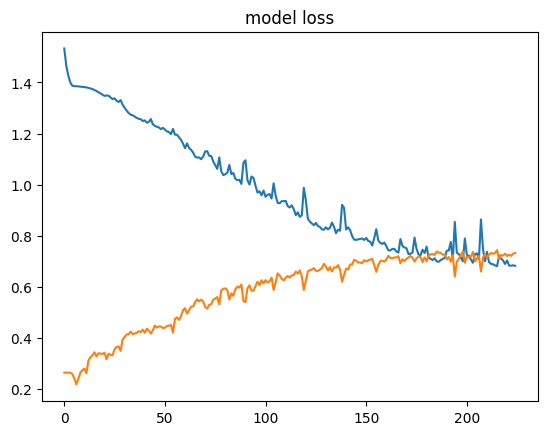

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model = Sequential()
model.add(LSTM(64, input_shape=(160, num_features)))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_x, train_y, epochs=225, batch_size=64)

plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

### LSTM Hyperparamger Tuning
Below is a fraction of the hyperparameter tuning that was performed for the LSTM model. Not all attempts were kept for the sake of brevity. Hyperparameter tuning of the LSTM consisted of deeper and shallower architectures, the use of dropout layers, varying numbers of nodes, different activation functions, different optimizers, different learning rates, and different batch sizes.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.2544 - loss: 1.4012 - val_accuracy: 0.2814 - val_loss: nan
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.2749 - loss: 1.3801 - val_accuracy: 0.0114 - val_loss: nan
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3093 - loss: 1.3752 - val_accuracy: 0.5411 - val_loss: nan
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.3908 - loss: 1.3348 - val_accuracy: 0.7372 - val_loss: nan
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3761 - loss: 1.3307 - val_accuracy: 0.8542 - val_loss: nan
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.3052 - loss: 1.3575 - val_accuracy: 0.7262 - val_loss: nan
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.4037 - loss: 1.3355 - val_accuracy: 0.6069 - val_loss: nan
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3862 - loss: 1.3170 - val_accuracy: 0.6128 - v

Text(0.5, 1.0, 'model loss')

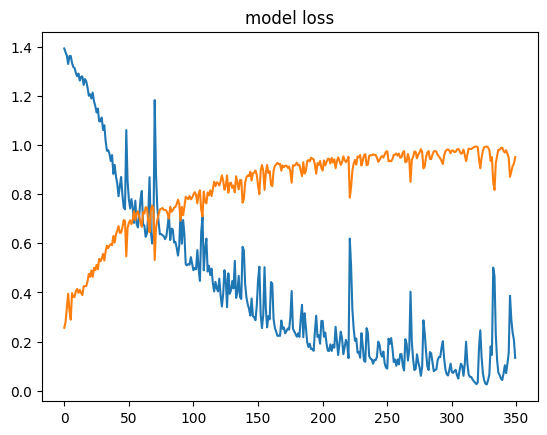

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

num_features = train_x.shape[2]

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(160, num_features)))
lstm_model.add(Dense(4, activation='sigmoid'))
lstm_model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model.summary())
lstm_hist = lstm_model.fit(train_x, train_y, epochs=350, batch_size=64, validation_data=(valid_x, valid_y))

# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.title('model loss')

### More Complex LSTM

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                       │ (None, 160, 32)             │           7,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 160, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_20 (LSTM)                       │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,348 (40.42 KB)

 Trainable params: 10,348 (40.42 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.2253 - loss: 1.4021
Epoch 2/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.2609 - loss: 1.3884
Epoch 3/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.2629 - loss: 1.3836
Epoch 4/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.2587 - loss: 1.3816
Epoch 5/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.2592 - loss: 1.3863
Epoch 6/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.2759 - loss: 1.3844
Epoch 7/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.2443 - loss: 1.3883
Epoch 8/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.2574 - loss: 1.3826
Epoch 9/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.2648 - loss: 1.3853
Epoch 10/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.3026 - loss: 1.3769
Epoch 11/225
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.2651 - loss: 1.3837
Epoch 12/225
23/23 ━━━━━━━━━━━━━━━━━

Text(0.5, 1.0, 'model loss')

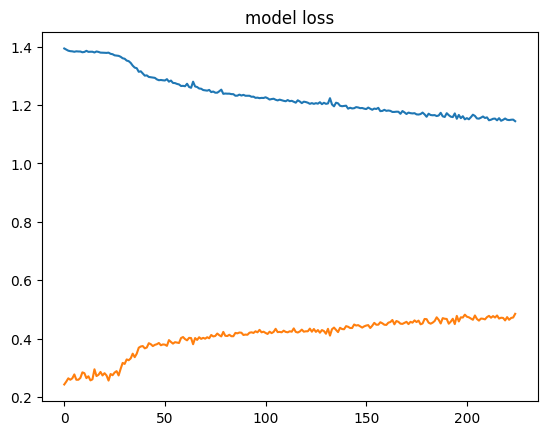

In [ ]:
m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model = Sequential()
model.add(LSTM(32, input_shape=(160, num_features), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(16))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_x, train_y, epochs=225, batch_size=64)

plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.2544 - loss: 1.4012 - val_accuracy: 0.2814 - val_loss: nan
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.2749 - loss: 1.3801 - val_accuracy: 0.0114 - val_loss: nan
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3093 - loss: 1.3752 - val_accuracy: 0.5411 - val_loss: nan
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.3908 - loss: 1.3348 - val_accuracy: 0.7372 - val_loss: nan
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3761 - loss: 1.3307 - val_accuracy: 0.8542 - val_loss: nan
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.3052 - loss: 1.3575 - val_accuracy: 0.7262 - val_loss: nan
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.4037 - loss: 1.3355 - val_accuracy: 0.6069 - val_loss: nan
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3862 - loss: 1.3170 - val_accuracy: 0.6128 - v

Text(0.5, 1.0, 'model loss')

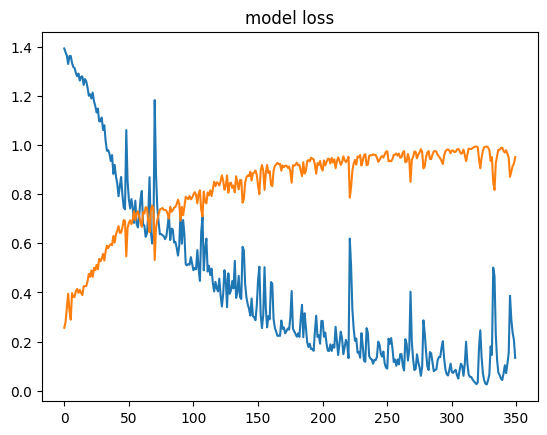

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

num_features = train_x.shape[2]

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(160, num_features)))
lstm_model.add(Dense(4, activation='sigmoid'))
lstm_model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model.summary())
lstm_hist = lstm_model.fit(train_x, train_y, epochs=350, batch_size=64, validation_data=(valid_x, valid_y))

# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.title('model loss')

Text(0.5, 1.0, 'model loss')

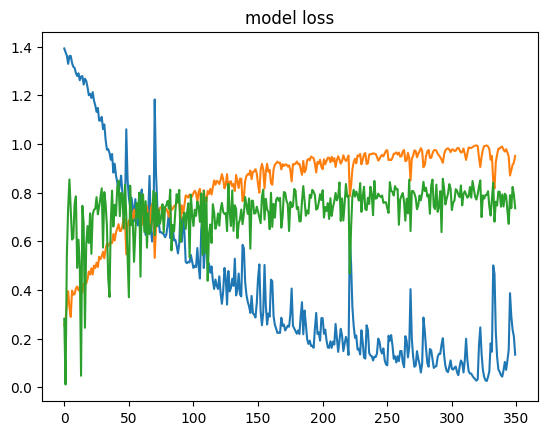

In [ ]:
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.plot(lstm_hist.history['val_accuracy'])
plt.title('model loss')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.2544 - loss: 1.4012 - val_accuracy: 0.2814 - val_loss: nan
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.2749 - loss: 1.3801 - val_accuracy: 0.0114 - val_loss: nan
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3093 - loss: 1.3752 - val_accuracy: 0.5411 - val_loss: nan
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.3908 - loss: 1.3348 - val_accuracy: 0.7372 - val_loss: nan
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3761 - loss: 1.3307 - val_accuracy: 0.8542 - val_loss: nan
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.3052 - loss: 1.3575 - val_accuracy: 0.7262 - val_loss: nan
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.4037 - loss: 1.3355 - val_accuracy: 0.6069 - val_loss: nan
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3862 - loss: 1.3170 - val_accuracy: 0.6128 - v

Text(0.5, 1.0, 'model loss')

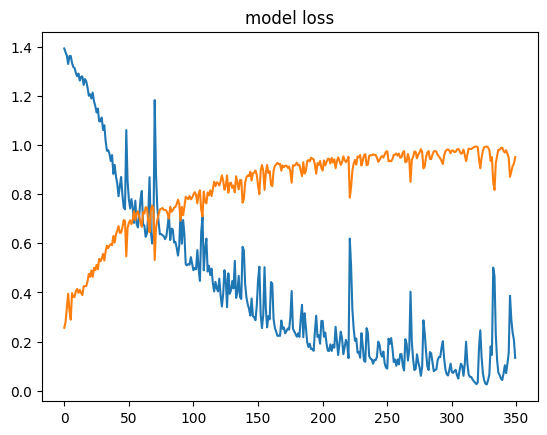

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

num_features = train_x.shape[2]

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(160, num_features)))
lstm_model.add(Dense(4, activation='sigmoid'))
lstm_model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model.summary())
lstm_hist = lstm_model.fit(train_x, train_y, epochs=350, batch_size=64, validation_data=(valid_x, valid_y))

# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.title('model loss')

Text(0.5, 1.0, 'model loss')

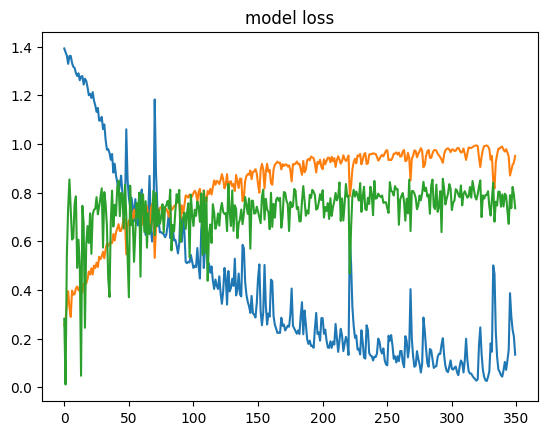

In [ ]:
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.plot(lstm_hist.history['val_accuracy'])
plt.title('model loss')

### Save Model

In [ ]:
model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel"
os.makedirs(model_dir, exist_ok=True)

model.export(model_dir)

tarball_name = "lstm_model.tar.gz"
with tarfile.open(tarball_name, "w:gz") as tar:
    tar.add(model_dir, arcname=os.path.basename(model_dir))

print(f"Model saved as {tarball_name}")

Saved artifact at '/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 22), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139820204656784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved as lstm_model.tar.gz


In [ ]:
valid_y_argmaxed = valid_y.argmax(axis=1)
print(classification_report(valid_y_argmaxed, preds.argmax(axis=1)))
print(preds)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      9146
           1       0.38      0.58      0.46       715
           2       0.19      0.69      0.29       225
           3       0.47      0.97      0.63        97

    accuracy                           0.83     10183
   macro avg       0.50      0.77      0.57     10183
weighted avg       0.91      0.83      0.86     10183

[[0.9692502  0.67852646 0.02187795 0.03043036]
 [0.9923308  0.02723334 0.00434992 0.88280094]
 [0.9900017  0.19605248 0.02492564 0.11360192]
 ...
 [0.0863151  0.5634494  0.00118054 0.9997788 ]
 [0.03979751 0.51264393 0.00385703 0.9998391 ]
 [0.93349063 0.04790827 0.00583803 0.98676866]]


In [ ]:
tree_model = DecisionTreeClassifier()
tree_model.fit(train_x_average, train_y_tree)

preds = tree_model.predict(valid_x_average)
print(classification_report(valid_y_tree, preds))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      9146
           1       0.27      0.62      0.38       715
           2       0.14      0.66      0.23       225
           3       0.11      0.68      0.19        97

    accuracy                           0.73     10183
   macro avg       0.38      0.68      0.41     10183
weighted avg       0.91      0.73      0.79     10183



In [ ]:
rf_model_experimental = RandomForestClassifier(n_estimators=50,
                                               max_depth=10,
                                               random_state=33)
rf_model_experimental.fit(train_x_average, train_y_tree)

rf_experimental_preds = rf_model_experimental.predict(valid_x_average)

print(classification_report(valid_y_tree, rf_experimental_preds))

In [ ]:
print(classification_report(valid_y_tree, preds))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      9146
           1       0.41      0.71      0.52       715
           2       0.31      0.75      0.44       225
           3       0.17      0.88      0.28        97

    accuracy                           0.84     10183
   macro avg       0.47      0.80      0.54     10183
weighted avg       0.93      0.84      0.87     10183



### Create Ensemble

In [ ]:
def load_models(lstm_model_dir, rf_model_dir):
    global lstm_model
    global rf_model
    lstm_model = tf.saved_model.load(lstm_model_dir)
    rf_model = joblib.load(rf_model_dir)
    return {"lstm": lstm_model, "rf": rf_model}

def gen_lstm_pre(lstm_model, input_data):
  reqd_shape = (1, 160, 22)
  padded_data = np.zeroes(reqd_shape)
  padded_data[0] = input_data
  padded_data.flat[:reqd_shape.size] = input_data
  return lstm_model.predict(padded_data)

def gen_rf_pred(rf_model, input_data):
  input_data = input_data.mean(axis=1)
  return rf_model.predict(input_data)

def gen_simultaneous_pred(input_data):
  with ProcessPoolExecutor() as executor:
    lstm_process = executor.submit(gen_lstm_pre, lstm_model, input_data)
    print("lstm process")
    rf_process = executor.submit(gen_rf_pred, rf_model, input_data)
    print("rf process")
    lstm_pred = lstm_process.result()
    print("lstm pred",lstm_pred)
    rf_pred = rf_process.result()
    print("rf pred",rf_pred)
    return lstm_pred, rf_pred

  alpha = 0.6
  beta = 0.4
  ensemble_probs = alpha * lstm_pred + beta * rf_pred
  pred = np.argmax(ensemble_probs, axis=1)
  return pred

### Save Models

In [ ]:
model_main_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/Models"

lstm_model_path = os.path.join(model_main_dir, "lstm_model")
rf_model_path = os.path.join(model_main_dir, "rf_model")
model.export(lstm_model_path)
joblib.dump(rf_model, rf_model_path)

Saved artifact at '/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/Models/lstm_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 22), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139820204656784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659856: TensorSpec(shape=(), dtype=tf.resource, name=None)


['/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/Models/rf_model']

In [ ]:
lstm_model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel"
rf_model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/rf_model/model.joblib"

load_models(lstm_model_path, rf_model_path)


valid_sample = valid_x[0]
valid_sample = np.expand_dims(valid_sample, axis=0)
print(valid_sample.shape)

valid_sample_pred = gen_simultaneous_pred(valid_sample)
print(valid_sample_pred)

### Save Random Forest Model & Generate Tarball

In [ ]:
forest_model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/rf_model"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(rf_model, os.path.join(model_dir, "model.joblib"))

tarball_name = "rf_model.tar.gz"
with tarfile.open(tarball_name, "w:gz") as tar:
    tar.add(model_dir, arcname=os.path.basename(model_dir))

print(f"Random Forest model saved and packaged as {tarball_name}")

!cp /content/rf_model.tar.gz /content/drive/MyDrive/USD (1)/FlightAnomalyClassification/rf_model.tar.gz


Random Forest model saved and packaged as rf_model.tar.gz


### More LSTM Experimentation

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 128)                 │          77,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,828 (304.02 KB)

 Trainable params: 77,828 (304.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.2469 - loss: 1.4117
Epoch 2/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.2683 - loss: 1.3875
Epoch 3/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.2705 - loss: 1.3823
Epoch 4/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.2700 - loss: 1.3835
Epoch 5/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.2509 - loss: 1.3828
Epoch 6/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.2586 - loss: 1.3850
Epoch 7/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.2652 - loss: 1.3856
Epoch 8/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.2932 - loss: 1.3784
Epoch 9/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.2754 - loss: 1.3828
Epoch 10/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.2855 - loss: 1.3824
Epoch 11/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.3268 - loss: 1.3716
Epoch 12/175
23/23 ━━━━━━━━━━━━━━━━━

Text(0.5, 1.0, 'model loss')

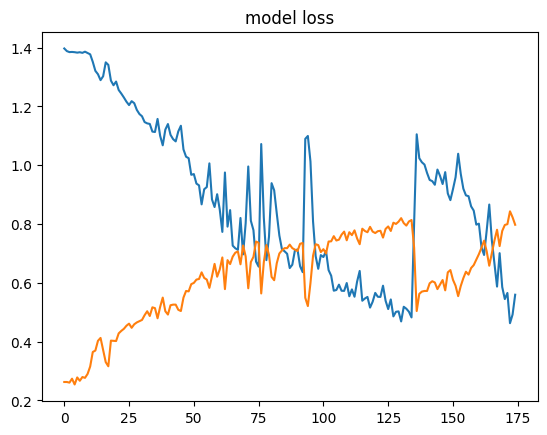

In [ ]:
model = Sequential()
model.add(LSTM(128, input_shape=(160, num_features)))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_x, train_y, epochs=175, batch_size=64)

plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 32)                  │           7,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,172 (28.02 KB)

 Trainable params: 7,172 (28.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.2875 - loss: 1.3812
Epoch 2/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2894 - loss: 1.3755
Epoch 3/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.2858 - loss: 1.3621
Epoch 4/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3203 - loss: 1.3558
Epoch 5/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3394 - loss: 1.3339
Epoch 6/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3237 - loss: 1.3435
Epoch 7/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3235 - loss: 1.3226
Epoch 8/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3274 - loss: 1.3295
Epoch 9/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3430 - loss: 1.3040
Epoch 10/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3632 - loss: 1.3073
Epoch 11/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3419 - loss: 1.2992
Epoch 12/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms

Text(0.5, 1.0, 'model loss')

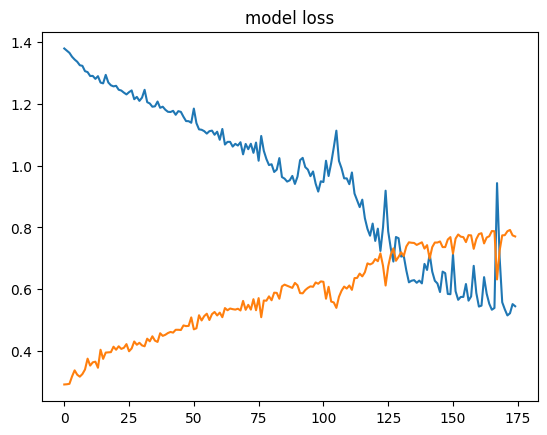

In [ ]:
model = Sequential()
model.add(LSTM(32, input_shape=(160, num_features)))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_x, train_y, epochs=175, batch_size=64)

plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,484 (95.64 KB)

 Trainable params: 24,484 (95.64 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.2620 - loss: 1.5620
Epoch 2/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.2796 - loss: 1.4527
Epoch 3/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.2436 - loss: 1.4381
Epoch 4/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.2523 - loss: 1.4342
Epoch 5/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3170 - loss: 1.3802
Epoch 6/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3529 - loss: 1.3564
Epoch 7/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3757 - loss: 1.3261
Epoch 8/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3138 - loss: 1.3921
Epoch 9/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3046 - loss: 1.3658
Epoch 10/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3360 - loss: 1.3618
Epoch 11/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3666 - loss: 1.3195
Epoch 12/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms

Text(0.5, 1.0, 'model loss')

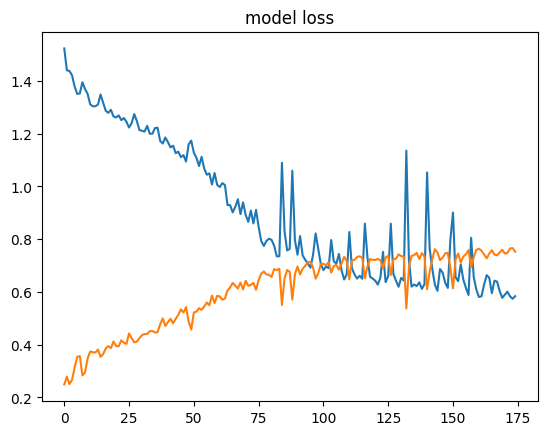

In [ ]:
model = Sequential()
model.add(LSTM(64, input_shape=(160, num_features)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='sigmoid'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_x, train_y, epochs=175, batch_size=64)

plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

In [ ]:
model = Sequential()
model.add(LSTM(64, input_shape=(160, num_features)))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_data, train_y, epochs=175, batch_size=64)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.2454 - loss: 1.4083
Epoch 2/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.2719 - loss: 1.3813
Epoch 3/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2836 - loss: 1.3794
Epoch 4/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.2477 - loss: 1.3831
Epoch 5/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3019 - loss: 1.3797
Epoch 6/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.2789 - loss: 1.3768
Epoch 7/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.2856 - loss: 1.3757
Epoch 8/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3113 - loss: 1.3753
Epoch 9/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3451 - loss: 1.3436
Epoch 10/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3680 - loss: 1.3155
Epoch 11/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3422 - loss: 1.3624
Epoch 12/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms

Text(0.5, 1.0, 'model loss')

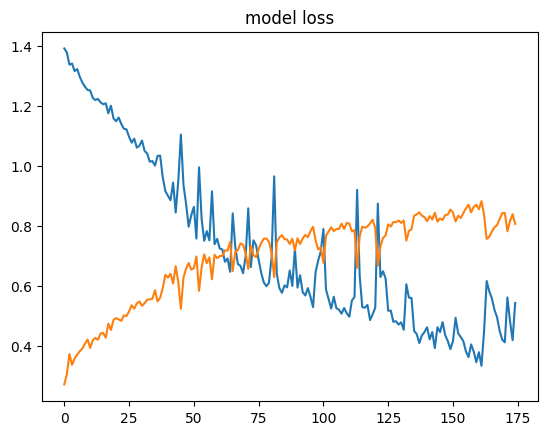

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

In [ ]:
num_samples = len(valid_x) // 160
num_features = valid_x.shape[1]

valid_data = valid_x.values.reshape((num_samples, 160, num_features))
valid_y = np.array(valid_y)
valid_data_y = []
for i in range(0,len(valid_y),160):
  valid_data_y.append(valid_y[i])

preds = model.predict(valid_data)

preds = np.argmax(preds, axis=1)
print(classification_report(valid_data_y, preds))

319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89      9146
         1.0       0.34      0.81      0.48       715
         2.0       0.21      0.70      0.32       225
         3.0       0.61      0.97      0.75        97

    accuracy                           0.81     10183
   macro avg       0.54      0.82      0.61     10183
weighted avg       0.92      0.81      0.85     10183



## Transformer Model

In [ ]:
class PosEncoding(nn.Module):
  def __init__(self, d_model, max_len=160):
    super(PosEncoding, self).__init__()
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer('pe', pe)

  def forward(self, x):
    return x + self.pe[:x.size(1), :].requires_grad_(False)

class TransformerClassifier(nn.Module):
  def __init__(self, feature_dim=22, d_model=64, num_heads=4, num_layers=5, dropout=0.1):
    super(TransformerClassifier, self).__init__()

    self.input_projection = nn.Linear(feature_dim, d_model)
    self.positional_encoding = PosEncoding(d_model)
    encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=256, dropout=dropout)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    self.classifier = nn.Linear(d_model, 4)

  def forward(self, x):
    x = self.input_projection(x)
    x = self.positional_encoding(x)
    x = self.transformer_encoder(x)
    x = x.mean(dim=1)
    return self.classifier(x)



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

def train_model(model, train_loader, num_epochs=10):
  model.train()
  for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()

      outputs = model(X_batch)
      loss = criterion(outputs, y_batch)
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader)}")

dataset = TensorDataset(train_x_tensor, train_y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=False)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
train_model(model, train_loader, num_epochs=30)

Epoch 1/30, Loss: 1.4289980867634648
Epoch 2/30, Loss: 1.398348813471587
Epoch 3/30, Loss: 1.3896784937900046
Epoch 4/30, Loss: 1.3892206679219785
Epoch 5/30, Loss: 1.4033911331840183
Epoch 6/30, Loss: 1.3860522612281467
Epoch 7/30, Loss: 1.3897192270859429
Epoch 8/30, Loss: 1.3929385879765386
Epoch 9/30, Loss: 1.393523211064546
Epoch 10/30, Loss: 1.392140445501908
Epoch 11/30, Loss: 1.3785965753638225
Epoch 12/30, Loss: 1.4102249715639197
Epoch 13/30, Loss: 1.3645772519318953
Epoch 14/30, Loss: 1.361972072850103
Epoch 15/30, Loss: 1.3483930722526882
Epoch 16/30, Loss: 1.3196298143138057
Epoch 17/30, Loss: 1.3226450111555017
Epoch 18/30, Loss: 1.3663232326507568
Epoch 19/30, Loss: 1.3700934752174045
Epoch 20/30, Loss: 1.357149398845175
Epoch 21/30, Loss: 1.3819449932678887
Epoch 22/30, Loss: 1.3555880525837773
Epoch 23/30, Loss: 1.3575434943904048
Epoch 24/30, Loss: 1.3472439309825068
Epoch 25/30, Loss: 1.3396538081376448
Epoch 26/30, Loss: 1.3330687336299731
Epoch 27/30, Loss: 1.33731

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report

valid_x_tensor = torch.tensor(train_data, dtype=torch.float32)
valid_y_tensor = torch.tensor(train_data_y, dtype=torch.long)

model.eval()
with torch.no_grad():
    preds = model(torch.tensor(valid_x_tensor, device=device))
    preds = preds.cpu().numpy()
    preds = np.argmax(preds, axis=1)

print(classification_report(train_data_y, preds))

<ipython-input-125-a770aae3145d>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  preds = model(torch.tensor(valid_x_tensor, device=device))


              precision    recall  f1-score   support

         0.0       0.45      0.89      0.60       380
         1.0       0.00      0.00      0.00       357
         2.0       0.00      0.00      0.00       313
         3.0       0.42      0.75      0.53       382

    accuracy                           0.44      1432
   macro avg       0.22      0.41      0.28      1432
weighted avg       0.23      0.44      0.30      1432



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## CNN Modeling

In [ ]:
def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model(input_shape=(160, 22))
cnn_model.summary()

In [ ]:
def create_improved_cnn_model(input_shape):
    model = Sequential()

    model.add(Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=256, kernel_size=5, activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(4, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0003), metrics=['accuracy'])

    return model

cnn_model = create_improved_cnn_model(input_shape=(160, 22))
cnn_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)                   │ (None, 156, 64)             │           7,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 156, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 78, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 74, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 74, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_12 (Conv1D)                   │ (None, 33, 256)             │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 33, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 247,492 (966.77 KB)

 Trainable params: 246,596 (963.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
train_y = np.array(train_y, dtype=np.float32)

In [ ]:
cnn_hist = cnn_model.fit(train_data, train_y, epochs=50, batch_size=64)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3714 - loss: 1.3543
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5919 - loss: 1.0175
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6968 - loss: 0.8135
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7761 - loss: 0.6302
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7707 - loss: 0.6076
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8160 - loss: 0.4887
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8102 - loss: 0.5023
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8315 - loss: 0.4522
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8333 - loss: 0.4246
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8723 - loss: 0.3766
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8918 - loss: 0.3512
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy:

Text(0.5, 1.0, 'model loss')

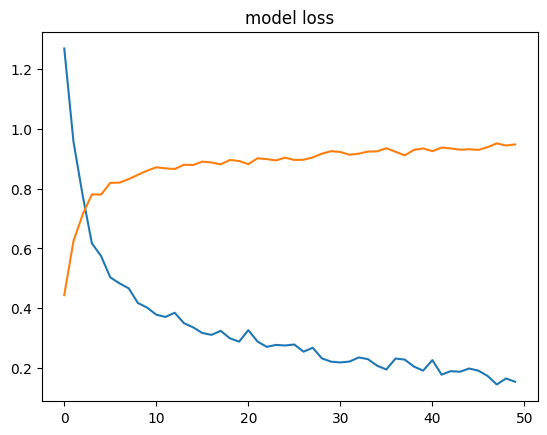

In [ ]:
plt.plot(cnn_hist.history['loss'])
plt.plot(cnn_hist.history['accuracy'])
plt.title('model loss')

In [ ]:
preds = cnn_model.predict(valid_data)
preds = np.argmax(preds, axis=1)
print(classification_report(valid_data_y, preds))

319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.03      0.05      9146
         1.0       0.07      1.00      0.14       715
         2.0       0.69      0.15      0.25       225
         3.0       0.82      0.48      0.61        97

    accuracy                           0.10     10183
   macro avg       0.65      0.42      0.26     10183
weighted avg       0.93      0.10      0.07     10183

